# SQL Sales & Business Analytics — Chinook Digital Music Store

**Goal:** Answer common data-analyst business questions — revenue, top customers, product performance, sales-rep
performance, and customer retention — using **SQL** (joins, aggregates, CTEs, and window functions) against a
relational database.

**Dataset:** [Chinook](https://github.com/lerocha/chinook-database) — a sample digital media store database
(customers, invoices, tracks, albums, artists, genres, employees), provided as SQLite at
[`data/chinook.sqlite`](../data/chinook.sqlite). See [`../schema.md`](../schema.md) for the entity relationships.

Every query below also lives as a standalone, reusable `.sql` file in [`../queries/`](../queries/), so they can be
read or run independently of this notebook.

---
### Contents
1. [Revenue overview](#1)
2. [Monthly revenue trend](#2)
3. [Top customers](#3)
4. [Revenue by country](#4)
5. [Top genres](#5)
6. [Top artists & tracks](#6)
7. [Sales rep performance](#7)
8. [Customer order frequency](#8)
9. [Window functions: running total & rank-within-group](#9)
10. [Key insights](#10)


In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]

conn = sqlite3.connect("../data/chinook.sqlite")

def run_query(path):
    """Read a .sql file, run it, return a DataFrame (a list of DataFrames if the file has more than one statement)."""
    sql = open(path).read()
    statements = []
    for chunk in sql.split(";"):
        lines = [line for line in chunk.splitlines() if not line.strip().startswith("--")]
        stmt = "\n".join(lines).strip()
        if stmt:
            statements.append(stmt)
    dfs = [pd.read_sql_query(s, conn) for s in statements]
    return dfs if len(dfs) > 1 else dfs[0]


<a id="1"></a>\n## 1. Revenue overview

In [2]:
print(open("../queries/01_revenue_overview.sql").read())
overview = run_query("../queries/01_revenue_overview.sql")
overview


-- Business question: What does the overall business look like — total revenue,
-- total orders, total customers, and average order value?

SELECT
    ROUND(SUM(Total), 2)                         AS total_revenue,
    COUNT(*)                                     AS total_invoices,
    COUNT(DISTINCT CustomerId)                   AS total_customers,
    ROUND(SUM(Total) * 1.0 / COUNT(*), 2)        AS avg_order_value,
    ROUND(SUM(Total) * 1.0 / COUNT(DISTINCT CustomerId), 2) AS avg_revenue_per_customer
FROM Invoice;



,total_revenue,total_invoices,total_customers,avg_order_value,avg_revenue_per_customer
0,2328.6,412,59,5.65,39.47


<a id="2"></a>\n## 2. Monthly revenue trend

In [3]:
print(open("../queries/02_monthly_revenue_trend.sql").read())
monthly = run_query("../queries/02_monthly_revenue_trend.sql")
monthly.head()


-- Business question: How has monthly revenue trended over time?

SELECT
    strftime('%Y-%m', InvoiceDate)   AS year_month,
    ROUND(SUM(Total), 2)            AS monthly_revenue,
    COUNT(*)                        AS invoice_count
FROM Invoice
GROUP BY year_month
ORDER BY year_month;



,year_month,monthly_revenue,invoice_count
0,2021-01,35.64,6
1,2021-02,37.62,7
2,2021-03,37.62,7
3,2021-04,37.62,7
4,2021-05,37.62,7


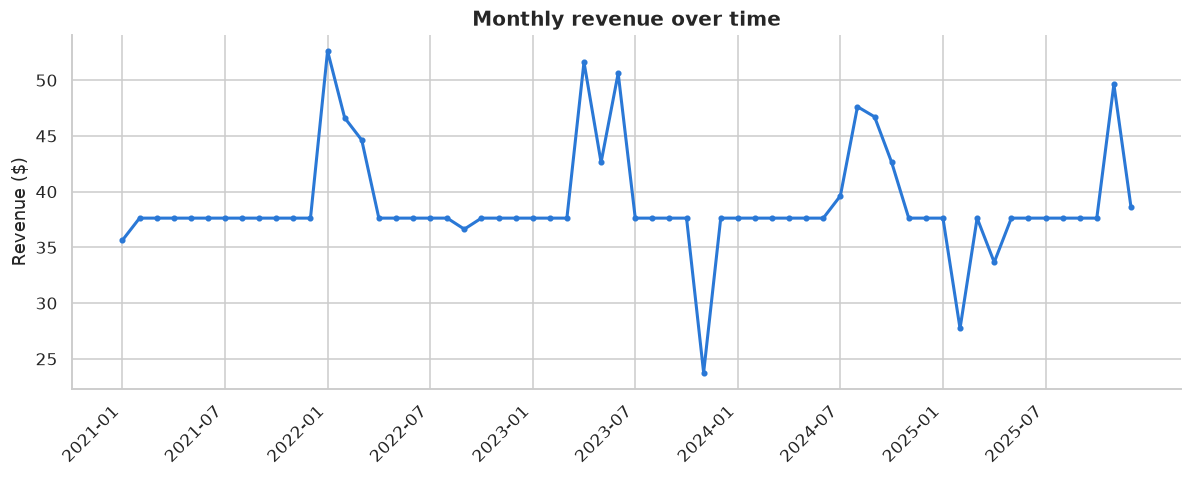

In [4]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(monthly["year_month"], monthly["monthly_revenue"], color=CATEGORICAL[0], linewidth=2, marker="o", markersize=3)
ax.set_title("Monthly revenue over time")
ax.set_ylabel("Revenue ($)")
ax.set_xticks(monthly["year_month"][::6])
ax.set_xticklabels(monthly["year_month"][::6], rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../images/01_monthly_revenue_trend.png", dpi=150, bbox_inches="tight")
plt.show()


<a id="3"></a>\n## 3. Top customers by lifetime revenue

In [5]:
print(open("../queries/03_top_customers.sql").read())
top_customers = run_query("../queries/03_top_customers.sql")
top_customers


-- Business question: Who are our top 10 customers by lifetime revenue?

SELECT
    c.CustomerId,
    c.FirstName || ' ' || c.LastName AS customer_name,
    c.Country,
    COUNT(i.InvoiceId)               AS orders,
    ROUND(SUM(i.Total), 2)           AS lifetime_revenue
FROM Customer c
JOIN Invoice i ON i.CustomerId = c.CustomerId
GROUP BY c.CustomerId, customer_name, c.Country
ORDER BY lifetime_revenue DESC
LIMIT 10;



,CustomerId,customer_name,Country,orders,lifetime_revenue
0,6,Helena Holý,Czech Republic,7,49.62
1,26,Richard Cunningham,USA,7,47.62
2,57,Luis Rojas,Chile,7,46.62
3,45,Ladislav Kovács,Hungary,7,45.62
4,46,Hugh O'Reilly,Ireland,7,45.62
5,24,Frank Ralston,USA,7,43.62
6,28,Julia Barnett,USA,7,43.62
7,37,Fynn Zimmermann,Germany,7,43.62
8,7,Astrid Gruber,Austria,7,42.62
9,25,Victor Stevens,USA,7,42.62


<a id="4"></a>\n## 4. Revenue by country

In [6]:
print(open("../queries/04_revenue_by_country.sql").read())
by_country = run_query("../queries/04_revenue_by_country.sql")
by_country


-- Business question: Which countries generate the most revenue, and how does
-- average order value differ by market?

SELECT
    BillingCountry                              AS country,
    COUNT(*)                                    AS invoices,
    COUNT(DISTINCT CustomerId)                  AS customers,
    ROUND(SUM(Total), 2)                        AS revenue,
    ROUND(SUM(Total) * 1.0 / COUNT(*), 2)       AS avg_order_value
FROM Invoice
GROUP BY country
ORDER BY revenue DESC
LIMIT 10;



,country,invoices,customers,revenue,avg_order_value
0,USA,91,13,523.06,5.75
1,Canada,56,8,303.96,5.43
2,France,35,5,195.10,5.57
3,Brazil,35,5,190.10,5.43
4,Germany,28,4,156.48,5.59
5,United Kingdom,21,3,112.86,5.37
6,Czech Republic,14,2,90.24,6.45
7,Portugal,14,2,77.24,5.52
8,India,13,2,75.26,5.79
9,Chile,7,1,46.62,6.66


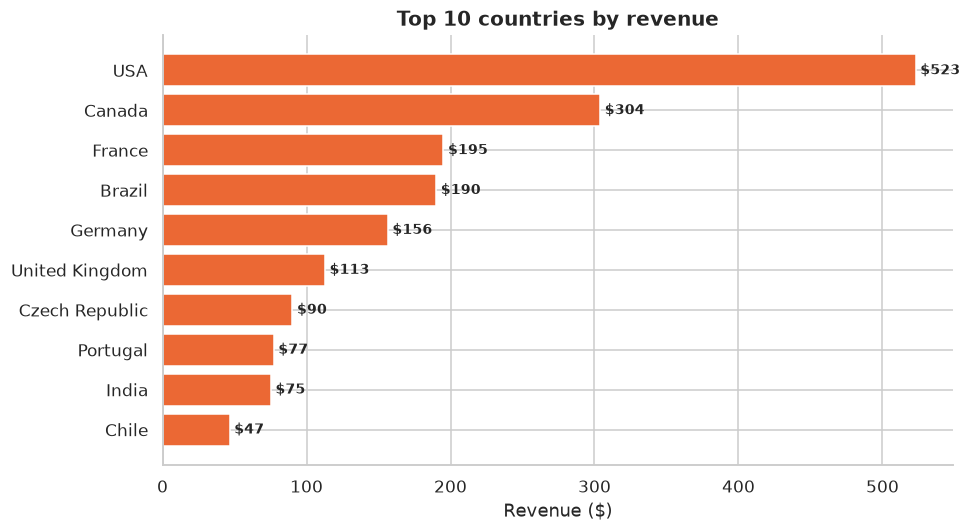

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(by_country["country"][::-1], by_country["revenue"][::-1], color=CATEGORICAL[1])
ax.set_title("Top 10 countries by revenue")
ax.set_xlabel("Revenue ($)")
for b, v in zip(bars, by_country["revenue"][::-1]):
    ax.annotate(f"${v:,.0f}", (v, b.get_y() + b.get_height() / 2), va="center", ha="left",
                 fontsize=9, fontweight="bold", xytext=(3, 0), textcoords="offset points")
plt.tight_layout()
plt.savefig("../images/02_revenue_by_country.png", dpi=150, bbox_inches="tight")
plt.show()


<a id="5"></a>\n## 5. Top genres by revenue

In [8]:
print(open("../queries/05_top_genres.sql").read())
top_genres = run_query("../queries/05_top_genres.sql")
top_genres


-- Business question: Which music genres sell best, by revenue and units sold?

SELECT
    g.Name                          AS genre,
    COUNT(il.InvoiceLineId)         AS units_sold,
    ROUND(SUM(il.UnitPrice * il.Quantity), 2) AS revenue
FROM InvoiceLine il
JOIN Track t  ON t.TrackId = il.TrackId
JOIN Genre g  ON g.GenreId = t.GenreId
GROUP BY genre
ORDER BY revenue DESC
LIMIT 10;



,genre,units_sold,revenue
0,Rock,835,826.65
1,Latin,386,382.14
2,Metal,264,261.36
3,Alternative & Punk,244,241.56
4,TV Shows,47,93.53
5,Jazz,80,79.20
6,Blues,61,60.39
7,Drama,29,57.71
8,R&B/Soul,41,40.59
9,Classical,41,40.59


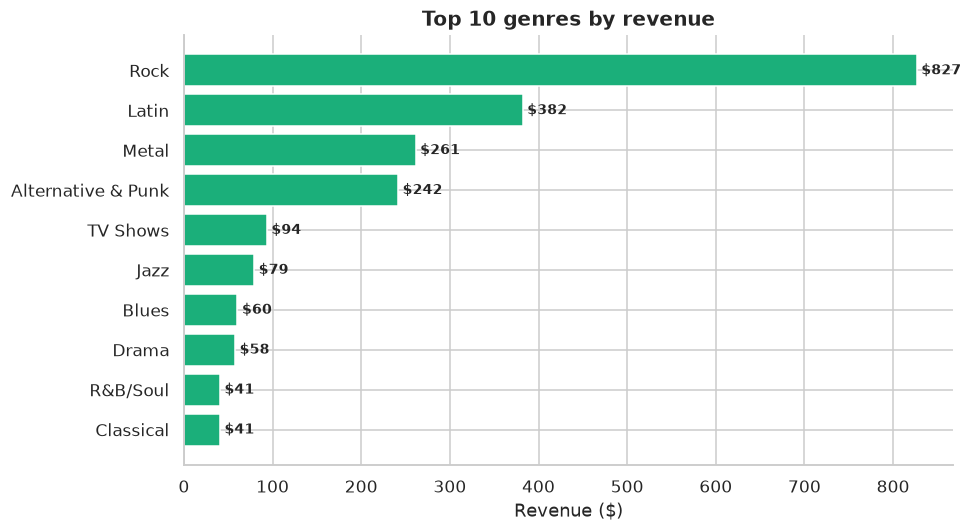

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top_genres["genre"][::-1], top_genres["revenue"][::-1], color=CATEGORICAL[2])
ax.set_title("Top 10 genres by revenue")
ax.set_xlabel("Revenue ($)")
for b, v in zip(bars, top_genres["revenue"][::-1]):
    ax.annotate(f"${v:,.0f}", (v, b.get_y() + b.get_height() / 2), va="center", ha="left",
                 fontsize=9, fontweight="bold", xytext=(3, 0), textcoords="offset points")
plt.tight_layout()
plt.savefig("../images/03_top_genres.png", dpi=150, bbox_inches="tight")
plt.show()


<a id="6"></a>\n## 6. Top artists & tracks by revenue

In [10]:
print(open("../queries/06_top_artists_tracks.sql").read())
top_artists, top_tracks = run_query("../queries/06_top_artists_tracks.sql")
top_artists


-- Business question: Which artists and individual tracks drive the most revenue?
-- (Two related queries: top artists, then top individual tracks.)

-- Top 10 artists by revenue
SELECT
    ar.Name                                    AS artist,
    COUNT(il.InvoiceLineId)                    AS units_sold,
    ROUND(SUM(il.UnitPrice * il.Quantity), 2)  AS revenue
FROM InvoiceLine il
JOIN Track t   ON t.TrackId = il.TrackId
JOIN Album al  ON al.AlbumId = t.AlbumId
JOIN Artist ar ON ar.ArtistId = al.ArtistId
GROUP BY artist
ORDER BY revenue DESC
LIMIT 10;

-- Top 10 individual tracks by revenue
SELECT
    t.Name                                     AS track,
    ar.Name                                    AS artist,
    COUNT(il.InvoiceLineId)                    AS units_sold,
    ROUND(SUM(il.UnitPrice * il.Quantity), 2)  AS revenue
FROM InvoiceLine il
JOIN Track t   ON t.TrackId = il.TrackId
JOIN Album al  ON al.AlbumId = t.AlbumId
JOIN Artist ar ON ar.ArtistId = al.ArtistId
GROUP BY t.Tra

,artist,units_sold,revenue
0,Iron Maiden,140,138.60
1,U2,107,105.93
2,Metallica,91,90.09
3,Led Zeppelin,87,86.13
4,Lost,41,81.59
5,The Office,25,49.75
6,Os Paralamas Do Sucesso,45,44.55
7,Deep Purple,44,43.56
8,Faith No More,42,41.58
9,Eric Clapton,40,39.60


In [11]:
top_tracks


,track,artist,units_sold,revenue
0,The Woman King,Battlestar Galactica,2,3.98
1,The Fix,Heroes,2,3.98
2,Walkabout,Lost,2,3.98
3,Hot Girl,The Office,2,3.98
4,Gay Witch Hunt,The Office,2,3.98
5,Phyllis's Wedding,The Office,2,3.98
6,How to Stop an Exploding Man,Heroes,2,3.98
7,Pilot,Aquaman,2,3.98
8,Occupation / Precipice,Battlestar Galactica,1,1.99
9,"Exodus, Pt. 1",Battlestar Galactica,1,1.99


<a id="7"></a>\n## 7. Sales rep performance

In [12]:
print(open("../queries/07_sales_rep_performance.sql").read())
reps = run_query("../queries/07_sales_rep_performance.sql")
reps


-- Business question: How does revenue break down by sales support representative
-- (each customer is assigned to one employee via SupportRepId)?

SELECT
    e.EmployeeId,
    e.FirstName || ' ' || e.LastName AS sales_rep,
    e.Title,
    COUNT(DISTINCT c.CustomerId)     AS customers_managed,
    COUNT(i.InvoiceId)               AS invoices_handled,
    ROUND(SUM(i.Total), 2)           AS revenue_generated
FROM Employee e
JOIN Customer c ON c.SupportRepId = e.EmployeeId
JOIN Invoice i  ON i.CustomerId = c.CustomerId
GROUP BY e.EmployeeId, sales_rep, e.Title
ORDER BY revenue_generated DESC;



,EmployeeId,sales_rep,Title,customers_managed,invoices_handled,revenue_generated
0,3,Jane Peacock,Sales Support Agent,21,146,833.04
1,4,Margaret Park,Sales Support Agent,20,140,775.40
2,5,Steve Johnson,Sales Support Agent,18,126,720.16


<a id="8"></a>\n## 8. Customer order frequency

In [13]:
print(open("../queries/08_repeat_customer_rate.sql").read())
repeat_rate = run_query("../queries/08_repeat_customer_rate.sql")
repeat_rate


-- Business question: What share of customers are repeat buyers (2+ orders)
-- vs. one-time buyers, and how much revenue does each group represent?

WITH customer_orders AS (
    SELECT
        CustomerId,
        COUNT(*)        AS order_count,
        SUM(Total)      AS customer_revenue
    FROM Invoice
    GROUP BY CustomerId
)
SELECT
    CASE WHEN order_count > 1 THEN 'Repeat customer' ELSE 'One-time customer' END AS segment,
    COUNT(*)                                   AS customers,
    ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM customer_orders), 1) AS pct_of_customers,
    ROUND(SUM(customer_revenue), 2)            AS total_revenue,
    ROUND(100.0 * SUM(customer_revenue) / (SELECT SUM(customer_revenue) FROM customer_orders), 1) AS pct_of_revenue
FROM customer_orders
GROUP BY segment;



,segment,customers,pct_of_customers,total_revenue,pct_of_revenue
0,Repeat customer,59,100.0,2328.6,100.0


Every customer in this dataset has placed more than one order — Chinook's sample data spreads purchases evenly
across the customer base, so this particular result reflects the demo dataset rather than a real churn/retention
signal. On a production database, this same query is exactly how you'd split one-time vs. repeat buyers and
compare their revenue contribution.


<a id="9"></a>\n## 9. Window functions: running total & rank-within-group

In [14]:
print(open("../queries/09_running_total_monthly_revenue.sql").read())
running = run_query("../queries/09_running_total_monthly_revenue.sql")
running.tail()


-- Business question: What does cumulative (running-total) revenue look like
-- month over month? Demonstrates a window function (SUM ... OVER).

WITH monthly AS (
    SELECT
        strftime('%Y-%m', InvoiceDate) AS year_month,
        SUM(Total)                     AS monthly_revenue
    FROM Invoice
    GROUP BY year_month
)
SELECT
    year_month,
    ROUND(monthly_revenue, 2) AS monthly_revenue,
    ROUND(SUM(monthly_revenue) OVER (ORDER BY year_month), 2) AS running_total_revenue
FROM monthly
ORDER BY year_month;



,year_month,monthly_revenue,running_total_revenue
55,2025-08,37.62,2165.12
56,2025-09,37.62,2202.74
57,2025-10,37.62,2240.36
58,2025-11,49.62,2289.98
59,2025-12,38.62,2328.60


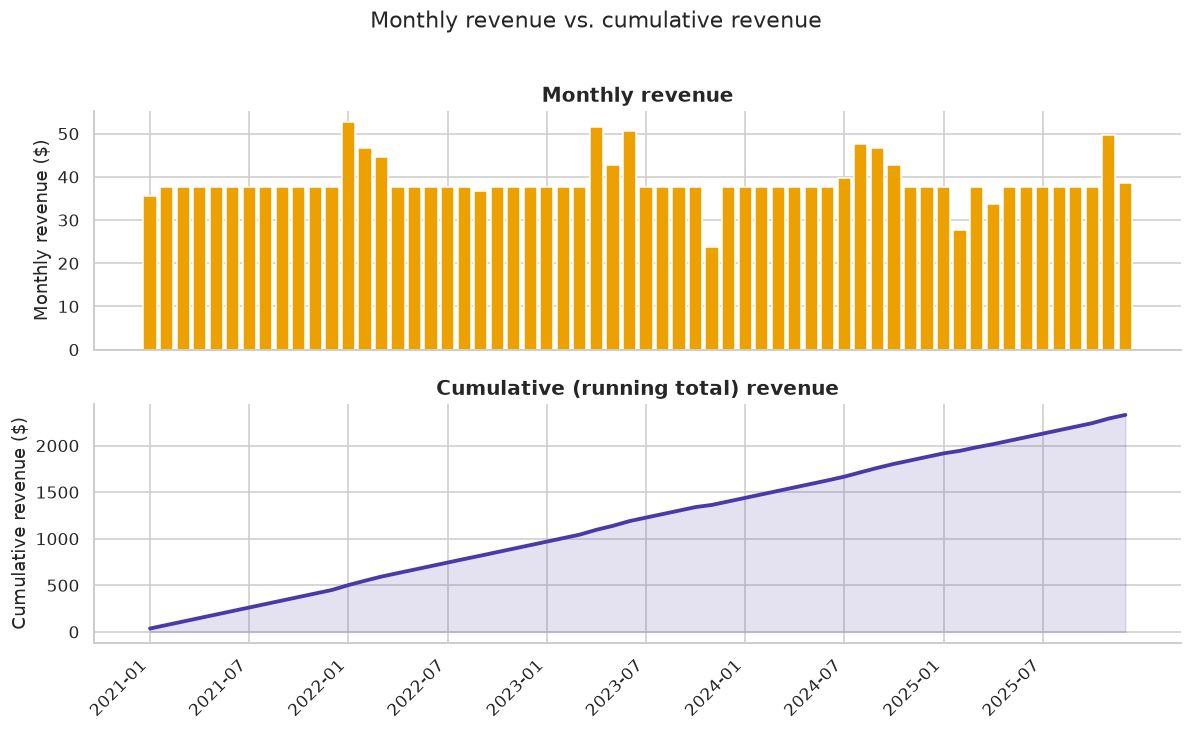

In [15]:
# Two stacked panels sharing one x-axis, rather than a dual-axis chart on one
# plot (a two-y-scale chart on a shared frame is easy to misread).
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)

ax1.bar(running["year_month"], running["monthly_revenue"], color=CATEGORICAL[3])
ax1.set_ylabel("Monthly revenue ($)")
ax1.set_title("Monthly revenue")

ax2.plot(running["year_month"], running["running_total_revenue"], color=CATEGORICAL[5], linewidth=2.5)
ax2.fill_between(running["year_month"], running["running_total_revenue"], color=CATEGORICAL[5], alpha=0.15)
ax2.set_ylabel("Cumulative revenue ($)")
ax2.set_title("Cumulative (running total) revenue")
ax2.set_xticks(running["year_month"][::6])
ax2.set_xticklabels(running["year_month"][::6], rotation=45, ha="right")

fig.suptitle("Monthly revenue vs. cumulative revenue", y=1.02)
plt.tight_layout()
plt.savefig("../images/04_running_total_revenue.png", dpi=150, bbox_inches="tight")
plt.show()


In [16]:
print(open("../queries/10_customer_rank_by_country.sql").read())
top_per_country = run_query("../queries/10_customer_rank_by_country.sql")
top_per_country.head(10)


-- Business question: Within each country, who is the #1 customer by revenue?
-- Demonstrates a window function (RANK ... OVER PARTITION BY).

WITH customer_revenue AS (
    SELECT
        c.Country,
        c.CustomerId,
        c.FirstName || ' ' || c.LastName AS customer_name,
        SUM(i.Total)                     AS revenue
    FROM Customer c
    JOIN Invoice i ON i.CustomerId = c.CustomerId
    GROUP BY c.Country, c.CustomerId, customer_name
),
ranked AS (
    SELECT
        *,
        RANK() OVER (PARTITION BY Country ORDER BY revenue DESC) AS rank_in_country
    FROM customer_revenue
)
SELECT Country, customer_name, ROUND(revenue, 2) AS revenue
FROM ranked
WHERE rank_in_country = 1
ORDER BY revenue DESC;



,Country,customer_name,revenue
0,Czech Republic,Helena Holý,49.62
1,USA,Richard Cunningham,47.62
2,Chile,Luis Rojas,46.62
3,Hungary,Ladislav Kovács,45.62
4,Ireland,Hugh O'Reilly,45.62
5,Germany,Fynn Zimmermann,43.62
6,Austria,Astrid Gruber,42.62
7,Finland,Terhi Hämäläinen,41.62
8,France,Isabelle Mercier,40.62
9,Netherlands,Johannes Van der Berg,40.62


<a id="10"></a>
## 10. Key insights

1. **412 orders from 59 customers generated $2,328.60 in total revenue**, an average order value of **$5.65**
   (Chinook sells individual tracks/albums, so order sizes are small) and **$39.47 average revenue per customer**.
2. **Revenue is geographically concentrated**: the USA alone accounts for roughly a quarter of total revenue
   (~$523 of ~$2,329), with Canada, France, Brazil, and Germany rounding out the next tier — a small number of
   markets drive most of the business.
3. **Rock is the dominant genre by a wide margin** (~$827 of revenue, more than double the next genre, Latin),
   suggesting inventory, marketing, and recommendation efforts should weight heavily toward Rock while still
   diversifying into the next few genres.
4. **Revenue is spread relatively evenly across sales reps** (Jane Peacock, Margaret Park, Steve Johnson each
   manage ~20 customers and generate broadly similar revenue) — no single rep is an outlier, which is itself a
   useful finding when auditing for workload or performance imbalances.
5. **Every customer has ordered more than once** — a byproduct of this being an evenly-generated demo dataset —
   but the query itself (`queries/08_repeat_customer_rate.sql`) is a directly reusable template for one-time vs.
   repeat customer segmentation on a real transactional database.
6. **Window functions add real analytical value here**: the running-total query turns monthly figures into a
   cumulative revenue trend line in one query (no app-side loop), and the `RANK() OVER (PARTITION BY country)`
   query identifies the top customer in every single market in one pass — both are common asks in analyst
   interviews and dashboards.

**Skills demonstrated:** multi-table `JOIN`s (up to 4 tables deep), `GROUP BY` aggregation, `CTE`s (`WITH`), and
window functions (`SUM() OVER`, `RANK() OVER PARTITION BY`) — plus turning raw SQL output into business-readable
summaries and charts with Pandas/Matplotlib.
